In [2]:
import os
import cv2

path = "../data/raw/kaggle_3m"

found = False

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".tif") and "_mask" not in file:
            img_path = os.path.join(root, file)
            mask_path = img_path.replace(".tif", "_mask.tif")

            img = cv2.imread(img_path)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            print("Image path:", img_path)
            print("Mask path:", mask_path)
            print("Image shape:", img.shape if img is not None else "Image not loaded")
            print("Mask shape:", mask.shape if mask is not None else "Mask not loaded")

            found = True
            break
    if found:
        break

print("Found:", found)

Image path: ../data/raw/kaggle_3m\TCGA_CS_4941_19960909\TCGA_CS_4941_19960909_1.tif
Mask path: ../data/raw/kaggle_3m\TCGA_CS_4941_19960909\TCGA_CS_4941_19960909_1_mask.tif
Image shape: (256, 256, 3)
Mask shape: (256, 256)
Found: True


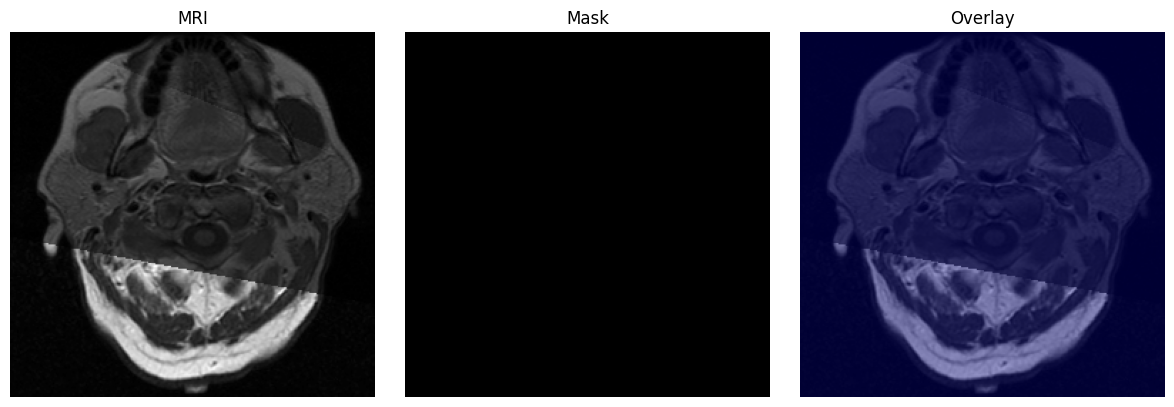

In [3]:
import matplotlib.pyplot as plt

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_gray, cmap="gray")
plt.title("MRI")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_gray, cmap="gray")
plt.imshow(mask, cmap="jet", alpha=0.4)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
import random
from pathlib import Path
from collections import Counter
import numpy as np
import cv2
import matplotlib.pyplot as plt


root = Path("../data/raw/kaggle_3m")
image_paths = sorted([p for p in root.rglob("*.tif") if "_mask" not in p.name])
mask_paths = [p.with_name(p.name.replace(".tif", "_mask.tif")) for p in image_paths]

print(f"Total images: {len(image_paths)}")
print(f"Mask paths exist: {sum(p.exists() for p in mask_paths)} / {len(mask_paths)}")

shape_counts = Counter()
mask_shape_counts = Counter()
missing_images = 0
missing_masks = 0

positive_masks_count = 0  # 1. To track slice-level class imbalance
negative_masks_count = 0
positive_coverages = []   # 2. To track tumor size distribution

#Background-skewed Pixel Intensities: Only track intensities where tumor is present (mask > 0)
foreground_blue = []
foreground_green = []
foreground_red = []

global_min_intensity = float('inf')
global_max_intensity = float('-inf')

# 4. Spatial Prior Analysis (Heatmap): Aggregate all masks
heatmap = None

case_tumor_counts = {}
case_total_counts = {}

for img_path, mask_path in zip(image_paths, mask_paths):
    case_name = img_path.parent.name
    case_total_counts[case_name] = case_total_counts.get(case_name, 0) + 1
    if case_name not in case_tumor_counts:
        case_tumor_counts[case_name] = 0

    img = cv2.imread(str(img_path))
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    if img is None:
        missing_images += 1
        continue
    if mask is None:
        missing_masks += 1
        continue

    shape_counts[img.shape] += 1
    mask_shape_counts[mask.shape] += 1
    
    # Track min and max for normalization check
    global_min_intensity = min(global_min_intensity, img.min())
    global_max_intensity = max(global_max_intensity, img.max())

    # Initialize heatmap dimension based on a mask shape
    if heatmap is None:
        heatmap = np.zeros(mask.shape, dtype=np.float32)

    coverage = (mask > 0).mean() * 100
    
    if coverage > 0:
        positive_masks_count += 1
        positive_coverages.append(coverage)
        case_tumor_counts[case_name] += 1
        
        # Add to spatial heatmap
        heatmap += (mask > 0).astype(np.float32)
        
        # Foreground intensity extraction (Sub-sampling every 50th pixel to save memory & time)
        foreground_mask = mask > 0
        foreground_blue.extend(img[:, :, 0][foreground_mask][::50].tolist())
        foreground_green.extend(img[:, :, 1][foreground_mask][::50].tolist())
        foreground_red.extend(img[:, :, 2][foreground_mask][::50].tolist())
    else:
        negative_masks_count += 1

print("Missing images:", missing_images)
print("Missing masks:", missing_masks)

for shape, count in shape_counts.most_common():
    print(f"  {shape}: {count} images")

print(f"Global Maximum Pixel Intensity: {global_max_intensity}")


Total images: 3929
Mask paths exist: 3929 / 3929


KeyboardInterrupt: 

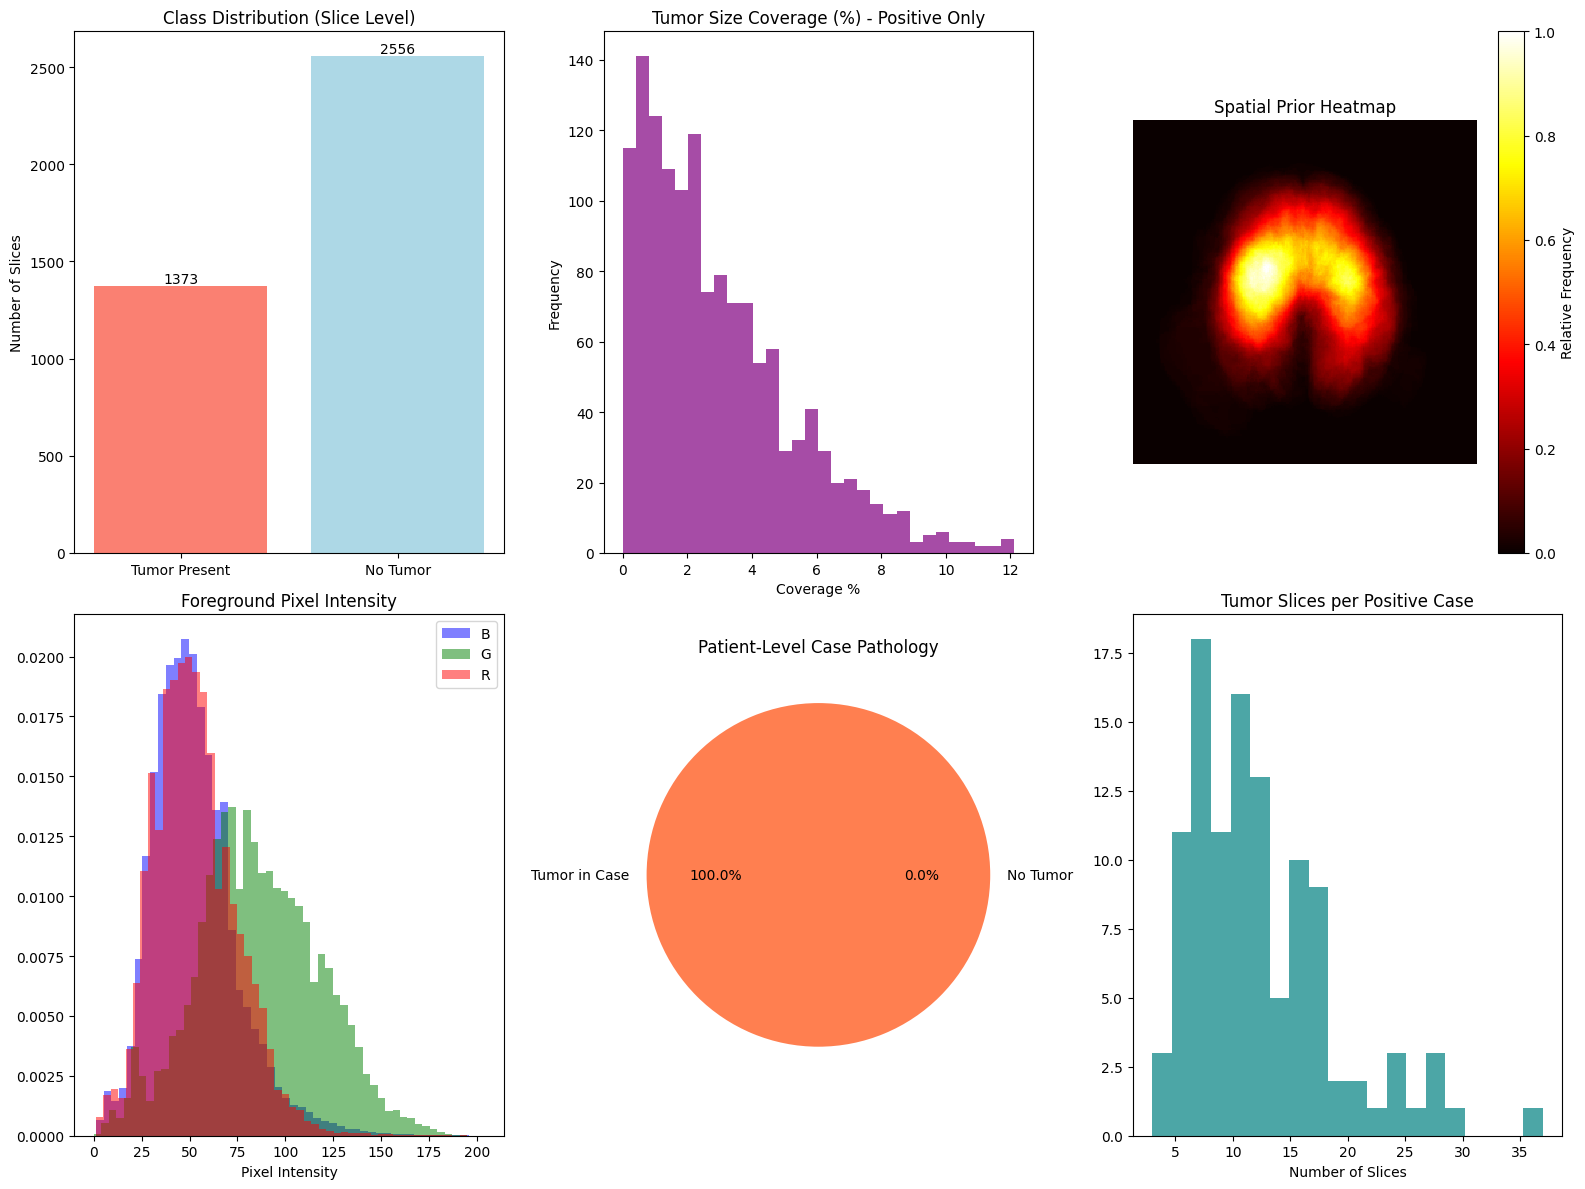

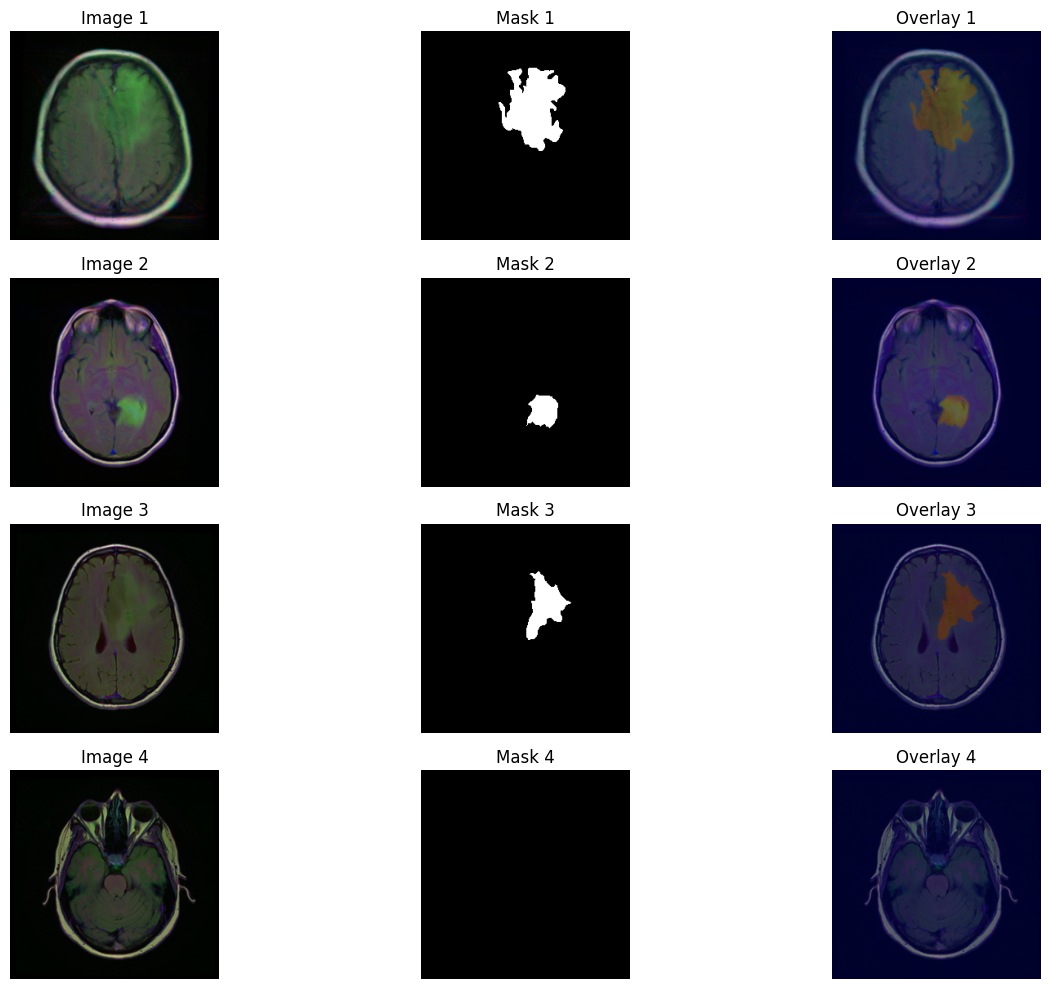

In [ ]:
# Visualizing all the newly collected metrics
plt.figure(figsize=(16, 12))

# 1. Class Distribution 
plt.subplot(2, 3, 1)
labels = ['Tumor Present', 'No Tumor']
counts = [positive_masks_count, negative_masks_count]
plt.bar(labels, counts, color=['salmon', 'lightblue'])
plt.title("Class Distribution (Slice Level)")
plt.ylabel("Number of Slices")
for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center', va='bottom')

# 2. Tumor Size Distribution
plt.subplot(2, 3, 2)
plt.hist(positive_coverages, bins=30, color='purple', alpha=0.7)
plt.title("Tumor Size Coverage (%) - Positive Only")
plt.xlabel("Coverage %")
plt.ylabel("Frequency")

# 4. Heatmap
plt.subplot(2, 3, 3)
if heatmap is not None:
    # Normalize heatmap
    heatmap_norm = heatmap / np.max(heatmap)
    plt.imshow(heatmap_norm, cmap='hot', interpolation='nearest')
    plt.colorbar(label='Relative Frequency')
    plt.title("Spatial Prior Heatmap")
    plt.axis("off")

# 3. Background-skewed Pixel Intensities, Foreground Only
plt.subplot(2, 3, 4)
plt.hist(foreground_blue, bins=50, color="blue", alpha=0.5, label='B', density=True)
plt.hist(foreground_green, bins=50, color="green", alpha=0.5, label='G', density=True)
plt.hist(foreground_red, bins=50, color="red", alpha=0.5, label='R', density=True)
plt.title("Foreground Pixel Intensity")
plt.xlabel("Pixel Intensity")
plt.legend()

# 6. Patient-level analysis
plt.subplot(2, 3, 5)
cases_with_tumor = sum(1 for c, v in case_tumor_counts.items() if v > 0)
cases_without_tumor = len(case_tumor_counts) - cases_with_tumor
plt.pie([cases_with_tumor, cases_without_tumor], labels=['Tumor in Case', 'No Tumor'], autopct='%1.1f%%', colors=['coral', 'lightgreen'])
plt.title("Patient-Level Case Pathology")

plt.subplot(2, 3, 6)
tumor_slices_per_case = [v for k, v in case_tumor_counts.items() if v > 0]
plt.hist(tumor_slices_per_case, bins=20, color='teal', alpha=0.7)
plt.title("Tumor Slices per Positive Case")
plt.xlabel("Number of Slices")

plt.tight_layout()
plt.show()

# Visualize a few random cases to understand dataset variation
random_samples = random.sample(image_paths, min(4, len(image_paths)))
plt.figure(figsize=(14, 10))
for i, img_path in enumerate(random_samples, start=1):
    mask_path = img_path.with_name(img_path.name.replace(".tif", "_mask.tif"))
    img = cv2.imread(str(img_path))
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(4, 3, 3 * (i - 1) + 1)
    plt.imshow(img_rgb)
    plt.title(f"Image {i}")
    plt.axis("off")

    plt.subplot(4, 3, 3 * (i - 1) + 2)
    plt.imshow(mask, cmap="gray")
    plt.title(f"Mask {i}")
    plt.axis("off")

    plt.subplot(4, 3, 3 * (i - 1) + 3)
    plt.imshow(img_rgb)
    plt.imshow(mask, cmap="jet", alpha=0.35)
    plt.title(f"Overlay {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [6]:
import numpy as np
print("Unique mask values:", np.unique(mask))

Unique mask values: [0]


In [7]:
import os
import cv2
import numpy as np

dataset_path = "../data/raw/kaggle_3m"

found_tumor_slice = False

for patient in os.listdir(dataset_path):
    patient_path = os.path.join(dataset_path, patient)
    if not os.path.isdir(patient_path):
        continue

    files = os.listdir(patient_path)
    images = [f for f in files if f.endswith(".tif") and "_mask" not in f]

    for img_file in images:
        mask_path = os.path.join(patient_path, img_file.replace(".tif", "_mask.tif"))
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        unique_vals = np.unique(mask)

        if len(unique_vals) > 1:
            print("Patient:", patient)
            print("Image file:", img_file)
            print("Unique mask values:", unique_vals)
            found_tumor_slice = True
            break

    if found_tumor_slice:
        break

print("Found tumor slice:", found_tumor_slice)

Patient: TCGA_CS_4941_19960909
Image file: TCGA_CS_4941_19960909_11.tif
Unique mask values: [  0 255]
Found tumor slice: True


In [8]:
import os

dataset_path = "../data/raw/kaggle_3m"

patient_folders = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]
print("Number of patient folders:", len(patient_folders))

total_images = 0
total_masks = 0

for patient in patient_folders:
    patient_path = os.path.join(dataset_path, patient)
    files = os.listdir(patient_path)
    
    images = [f for f in files if f.endswith(".tif") and "_mask" not in f]
    masks = [f for f in files if f.endswith(".tif") and "_mask" in f]
    
    total_images += len(images)
    total_masks += len(masks)

print("Total image slices:", total_images)
print("Total mask slices:", total_masks)

Number of patient folders: 110
Total image slices: 3929
Total mask slices: 3929


In [9]:
import os

dataset_path = "../data/raw/kaggle_3m"
bad_pairs = []

for patient in os.listdir(dataset_path):
    patient_path = os.path.join(dataset_path, patient)
    if not os.path.isdir(patient_path):
        continue
        
    files = os.listdir(patient_path)
    images = [f for f in files if f.endswith(".tif") and "_mask" not in f]
    
    for img_file in images:
        mask_file = img_file.replace(".tif", "_mask.tif")
        mask_path = os.path.join(patient_path, mask_file)
        
        if not os.path.exists(mask_path):
            bad_pairs.append((patient, img_file))

print("Number of missing mask pairs:", len(bad_pairs))
if bad_pairs[:5]:
    print("Examples:", bad_pairs[:5])

Number of missing mask pairs: 0


In [10]:
import os
import cv2

dataset_path = "../data/raw/kaggle_3m"

image_shapes = set()
mask_shapes = set()

for patient in os.listdir(dataset_path):
    patient_path = os.path.join(dataset_path, patient)
    if not os.path.isdir(patient_path):
        continue
        
    files = os.listdir(patient_path)
    images = [f for f in files if f.endswith(".tif") and "_mask" not in f]
    
    for img_file in images:
        img_path = os.path.join(patient_path, img_file)
        mask_path = os.path.join(patient_path, img_file.replace(".tif", "_mask.tif"))
        
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        image_shapes.add(img.shape)
        mask_shapes.add(mask.shape)

print("Unique image shapes:", image_shapes)
print("Unique mask shapes:", mask_shapes)

Unique image shapes: {(256, 256)}
Unique mask shapes: {(256, 256)}


In [11]:
import os
import pandas as pd

dataset_path = "../data/raw/kaggle_3m"
records = []

for patient in os.listdir(dataset_path):
    patient_path = os.path.join(dataset_path, patient)
    if not os.path.isdir(patient_path):
        continue

    files = os.listdir(patient_path)
    images = [f for f in files if f.endswith(".tif") and "_mask" not in f]

    for img_file in images:
        img_path = os.path.join(patient_path, img_file)
        mask_path = os.path.join(patient_path, img_file.replace(".tif", "_mask.tif"))

        if os.path.exists(mask_path):
            records.append({
                "patient_id": patient,
                "image_path": img_path,
                "mask_path": mask_path
            })

df = pd.DataFrame(records)
print(df.head())
print("Total samples:", len(df))
print("Total patients:", df["patient_id"].nunique())

              patient_id                                         image_path  \
0  TCGA_CS_4941_19960909  ../data/raw/kaggle_3m\TCGA_CS_4941_19960909\TC...   
1  TCGA_CS_4941_19960909  ../data/raw/kaggle_3m\TCGA_CS_4941_19960909\TC...   
2  TCGA_CS_4941_19960909  ../data/raw/kaggle_3m\TCGA_CS_4941_19960909\TC...   
3  TCGA_CS_4941_19960909  ../data/raw/kaggle_3m\TCGA_CS_4941_19960909\TC...   
4  TCGA_CS_4941_19960909  ../data/raw/kaggle_3m\TCGA_CS_4941_19960909\TC...   

                                           mask_path  
0  ../data/raw/kaggle_3m\TCGA_CS_4941_19960909\TC...  
1  ../data/raw/kaggle_3m\TCGA_CS_4941_19960909\TC...  
2  ../data/raw/kaggle_3m\TCGA_CS_4941_19960909\TC...  
3  ../data/raw/kaggle_3m\TCGA_CS_4941_19960909\TC...  
4  ../data/raw/kaggle_3m\TCGA_CS_4941_19960909\TC...  
Total samples: 3929
Total patients: 110


In [12]:
from sklearn.model_selection import train_test_split

patients = df["patient_id"].unique()

train_patients, temp_patients = train_test_split(
    patients, test_size=0.3, random_state=42
)

val_patients, test_patients = train_test_split(
    temp_patients, test_size=0.5, random_state=42
)

train_df = df[df["patient_id"].isin(train_patients)].reset_index(drop=True)
val_df = df[df["patient_id"].isin(val_patients)].reset_index(drop=True)
test_df = df[df["patient_id"].isin(test_patients)].reset_index(drop=True)

print("Train patients:", train_df["patient_id"].nunique())
print("Val patients:", val_df["patient_id"].nunique())
print("Test patients:", test_df["patient_id"].nunique())

print("Train samples:", len(train_df))
print("Val samples:", len(val_df))
print("Test samples:", len(test_df))

Train patients: 77
Val patients: 16
Test patients: 17
Train samples: 2750
Val samples: 618
Test samples: 561


In [13]:
import os

os.makedirs("../data/processed", exist_ok=True)

train_df.to_csv("../data/processed/train.csv", index=False)
val_df.to_csv("../data/processed/val.csv", index=False)
test_df.to_csv("../data/processed/test.csv", index=False)

In [1]:
import albumentations as A

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.2),
])

In [2]:
val_transform = A.Compose([
])

In [11]:
import torch
import sys
sys.path.append("..")

from src.dataset import LGGSegmentationDataset
from src.augmentations import get_train_transforms

train_dataset = LGGSegmentationDataset(
    csv_file="../data/processed/train.csv",
    transform=get_train_transforms()
)

for i in range(20):
    image, mask = train_dataset[i]
    unique_vals = torch.unique(mask)
    if len(unique_vals) > 1:
        print("Found tumor slice at index:", i)
        print("Mask unique values:", unique_vals)
        break

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Image dtype:", image.dtype)
print("Mask dtype:", mask.dtype)
print("Image min/max:", image.min().item(), image.max().item())
print("Mask unique values:", torch.unique(mask))

Found tumor slice at index: 1
Mask unique values: tensor([0., 1.])
Image shape: torch.Size([1, 256, 256])
Mask shape: torch.Size([1, 256, 256])
Image dtype: torch.float32
Mask dtype: torch.float32
Image min/max: 0.0 0.7490196228027344
Mask unique values: tensor([0., 1.])


In [3]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import src.model
print(dir(src.model))

import torch
from src.model import UNet

model = UNet(in_channels=1, out_channels=1)

x = torch.randn(1, 1, 256, 256)  # batch of 1 image
y = model(x)

print("Input shape:", x.shape)
print("Output shape:", y.shape)

['UNet', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'nn', 'torch']


TypeError: descriptor '__init__' of 'super' object needs an argument